In [15]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent ))

In [16]:
from src.dominick import DominickDataLoader
from src.eda import EDA

loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")
eda = EDA()

In [ ]:
upc = 8066095605
store = 126

In [18]:
print("=" * 80)
print(f"ESTUDIO COMPLETO PARA UPC {upc} | TIENDA {store}")
print("=" * 80)

# 1. Filtrado por UPC
df_upc = df[(df["upc_code"] == upc) & (df["store_code"] == store)].copy()
print(f"Nº observaciones para UPC {upc} | TIENDA {store}: {len(df_upc)}")

if df_upc.empty:
    print("No hay datos para este UPC.")

ESTUDIO COMPLETO PARA UPC 8066095605 | TIENDA 126
Nº observaciones para UPC 8066095605 | TIENDA 126: 300


In [19]:
# -------------------------------------------------------------------------
# 2. Análisis de NaNs
# -------------------------------------------------------------------------
print("\n=== NaNs ===")
nan_df = eda.analyze_nans(df_upc)
display(nan_df)


=== NaNs ===


,n_nans,pct_nans
store_code,0,0.0
upc_code,0,0.0
week_id,0,0.0
liters_per_upc,0,0.0
promo_B,0,0.0
promo_C,0,0.0
promo_S,0,0.0
log_price_per_liter,0,0.0
log_liters_sold,0,0.0



=== Correlación por tienda (Spearman) ===


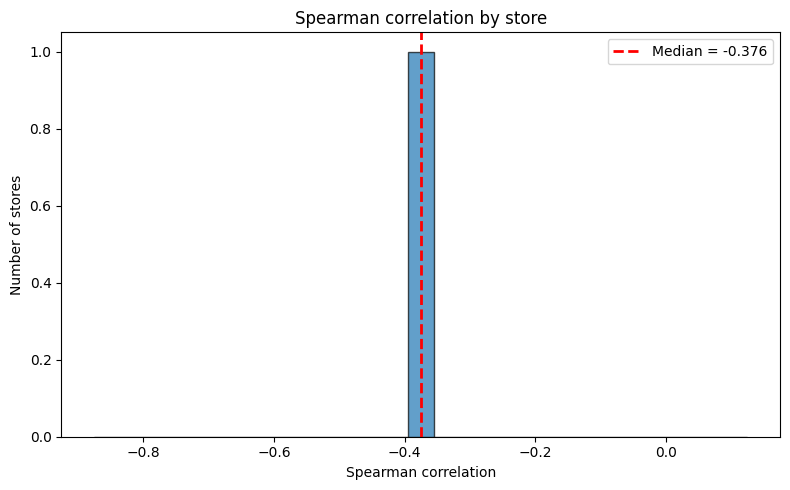

In [20]:
# -------------------------------------------------------------------------
# 3. Correlaciones por tienda
# -------------------------------------------------------------------------
print("\n=== Correlación por tienda (Spearman) ===")
corr_by_store = eda.analyze_correlations(
    df_upc,
    x_col="log_liters_sold",
    y_col="log_price_per_liter",
    group_col="store_code",
    min_obs=10,
)
ax_corr = eda.plot_correlations(corr_by_store)


=== Global Correlation Analysis (UPC) ===

Pearson: r = -0.4877, p = 2.5079e-19
Spearman: ρ = -0.3756, p = 1.7423e-11

Linear regression:
  R² = 0.2378
  Elasticity (β) = -3.2362
  Intercept = 6.2277
  p-value = 0.0000e+00


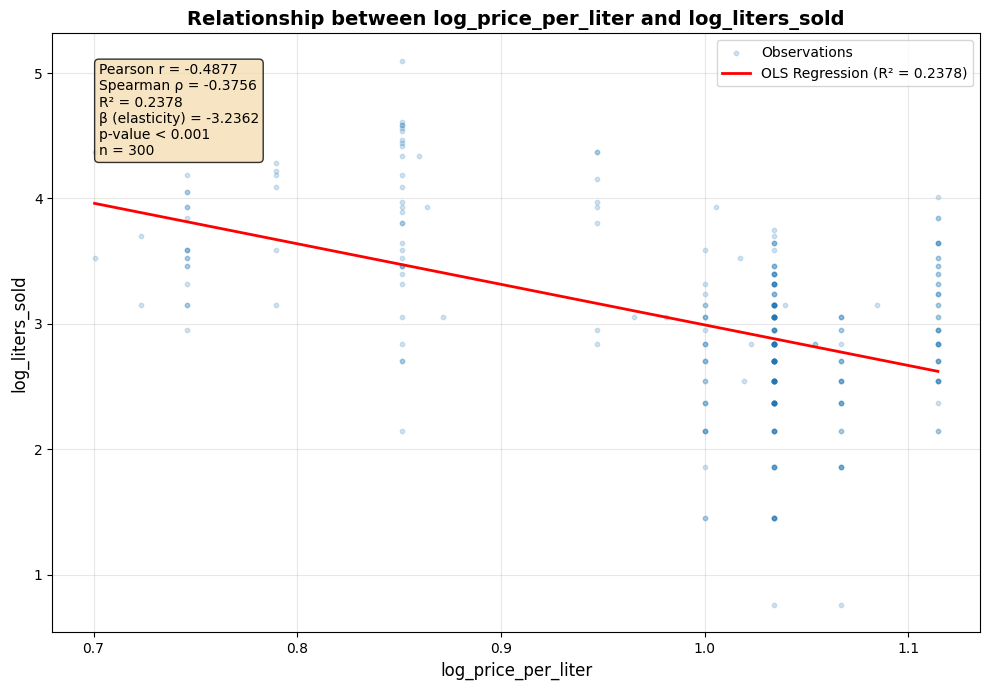

In [21]:
# -------------------------------------------------------------------------
# 4. Correlación global + regresión
# -------------------------------------------------------------------------
print("\n=== Global Correlation Analysis (UPC) ===")
x_col = "log_price_per_liter"
y_col = "log_liters_sold"

corr_stats = eda.analyze_global_correlation(df_upc, x_col, y_col)

print(
    f"\nPearson: r = {corr_stats['pearson']['correlation']:.4f}, "
    f"p = {corr_stats['pearson']['pvalue']:.4e}"
)
print(
    f"Spearman: ρ = {corr_stats['spearman']['correlation']:.4f}, "
    f"p = {corr_stats['spearman']['pvalue']:.4e}"
)

print("\nLinear regression:")
print(f"  R² = {corr_stats['regression']['r_squared']:.4f}")
print(f"  Elasticity (β) = {corr_stats['regression']['slope']:.4f}")
print(f"  Intercept = {corr_stats['regression']['intercept']:.4f}")
print(f"  p-value = {corr_stats['regression']['pvalue']:.4e}")

fig_scatter = eda.plot_scatter_regression(
    df_upc,
    x_col,
    y_col,
    sample_size=10000,
    stats_dict=corr_stats,
    alpha=0.2,
)


=== Descriptive Statistics (UPC) ===

log_price_per_liter:
  Mean: 0.9972
  Median: 1.0343
  Std: 0.1046
  Min: 0.7005, Max: 1.1145
  Q25: 1.0003, Q75: 1.0343
  Skewness: -1.2712, Kurtosis: 0.6522
  Normality test (Shapiro-Wilk): p-value = 0.0000

log_liters_sold:
  Mean: 3.0005
  Median: 2.9530
  Std: 0.6939
  Min: 0.7558, Max: 5.0996
  Q25: 2.5476, Q75: 3.4121
  Skewness: -0.0041, Kurtosis: 0.5112
  Normality test (Shapiro-Wilk): p-value = 0.0104

=== Histograms ===


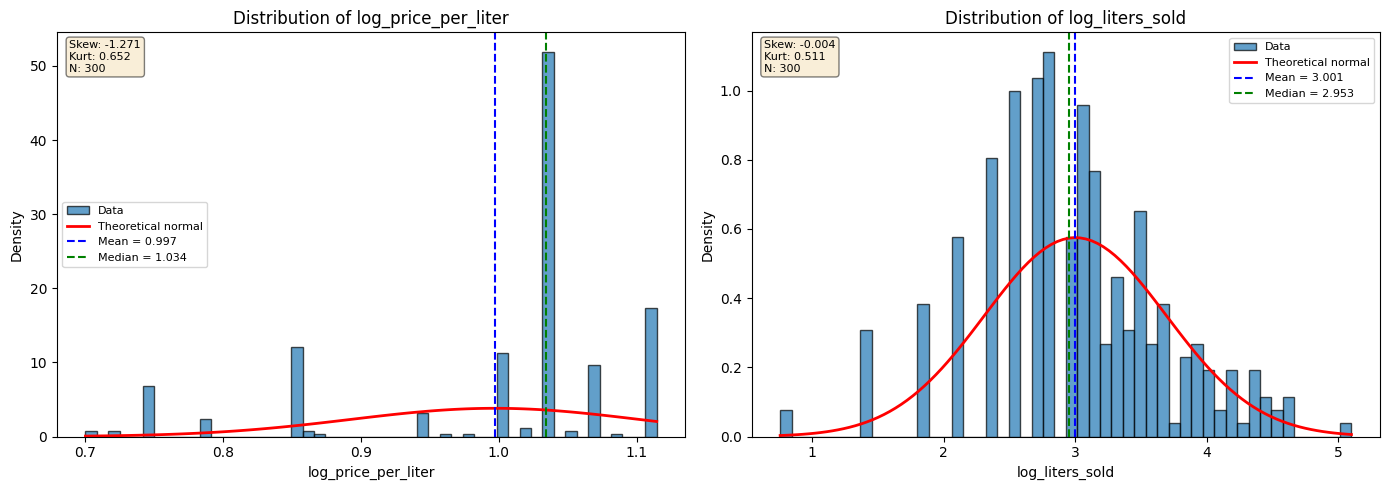

In [22]:
# -------------------------------------------------------------------------
# 5. Distribuciones + histogramas
# -------------------------------------------------------------------------
print("\n=== Descriptive Statistics (UPC) ===")
columns_to_analyze = ["log_price_per_liter", "log_liters_sold"]

stats = eda.analyze_distributions(df_upc, columns_to_analyze)
for col, s in stats.items():
    print(f"\n{col}:")
    print(f"  Mean: {s['mean']:.4f}")
    print(f"  Median: {s['median']:.4f}")
    print(f"  Std: {s['std']:.4f}")
    print(f"  Min: {s['min']:.4f}, Max: {s['max']:.4f}")
    print(f"  Q25: {s['q25']:.4f}, Q75: {s['q75']:.4f}")
    print(f"  Skewness: {s['skewness']:.4f}, Kurtosis: {s['kurtosis']:.4f}")
    print(
        f"  Normality test ({s['normality_test']['test_name']}): "
        f"p-value = {s['normality_test']['pvalue']:.4f}"
    )

print("\n=== Histograms ===")
fig_dists = eda.plot_distributions(
    df_upc,
    columns_to_analyze,
    bins=50,
    stats_dict=stats,
)

In [23]:
# -------------------------------------------------------------------------
# 6. Outliers
# -------------------------------------------------------------------------
print("\n=== Outliers (±3 std) ===")
outliers_std = eda.analyze_outliers(
    df_upc,
    columns_to_analyze,
    method="std",
    n_std=3,
)
print(outliers_std)

print("\n=== Outliers (IQR) ===")
outliers_iqr = eda.analyze_outliers(
    df_upc,
    columns_to_analyze,
    method="iqr",
)
print(outliers_iqr)


=== Outliers (±3 std) ===
              variable  n_outliers  pct_outliers  lower_bound  upper_bound  \
0  log_price_per_liter           0           0.0       0.6835       1.3109   
1      log_liters_sold           3           1.0       0.9189       5.0821   

   method  
0  ±3 std  
1  ±3 std  

=== Outliers (IQR) ===
              variable  n_outliers  pct_outliers  lower_bound  upper_bound  \
0  log_price_per_liter         111          37.0       0.9494       1.0852   
1      log_liters_sold           3           1.0       1.2507       4.7089   

      method  
0  IQR (1.5)  
1  IQR (1.5)  



=== Boxplots ===


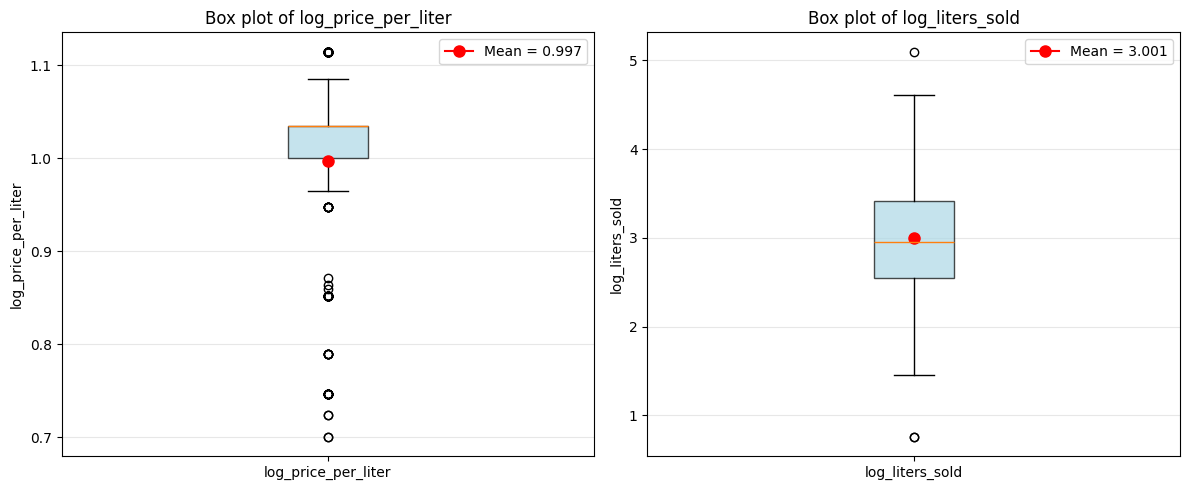

In [24]:
# -------------------------------------------------------------------------
# 7. Boxplots
# -------------------------------------------------------------------------
print("\n=== Boxplots ===")
fig_box = eda.plot_boxplots(df_upc, columns_to_analyze)

In [25]:
# -------------------------------------------------------------------------
# 8. Análisis temporal (agregado semanal)
# -------------------------------------------------------------------------
print("\n=== Temporal Aggregation (UPC) ===")
time_col = "week_id"
value_cols = ["log_price_per_liter", "log_liters_sold"]

ts_df = eda.aggregate_time_series(
    df_upc,
    time_col=time_col,
    value_cols=value_cols,
    agg_func="mean",
)
print(f"Time series: {len(ts_df)} weeks")
print(ts_df.head())


=== Temporal Aggregation (UPC) ===
Time series: 300 weeks
   week_id  log_price_per_liter  log_liters_sold
0       91             1.000338         3.058376
1       92             1.000338         2.142085
2       93             0.723531         3.700229
3       94             0.723531         3.153686
4       95             1.000338         3.240697



=== Trend Analysis ===

log_price_per_liter:
  Slope: 0.000288
  R²: 0.0622
  p-value: 1.2324e-05
  Trend: upward

log_liters_sold:
  Slope: 0.002077
  R²: 0.0734
  p-value: 1.9099e-06
  Trend: upward

=== Time Series + Trend Plots ===


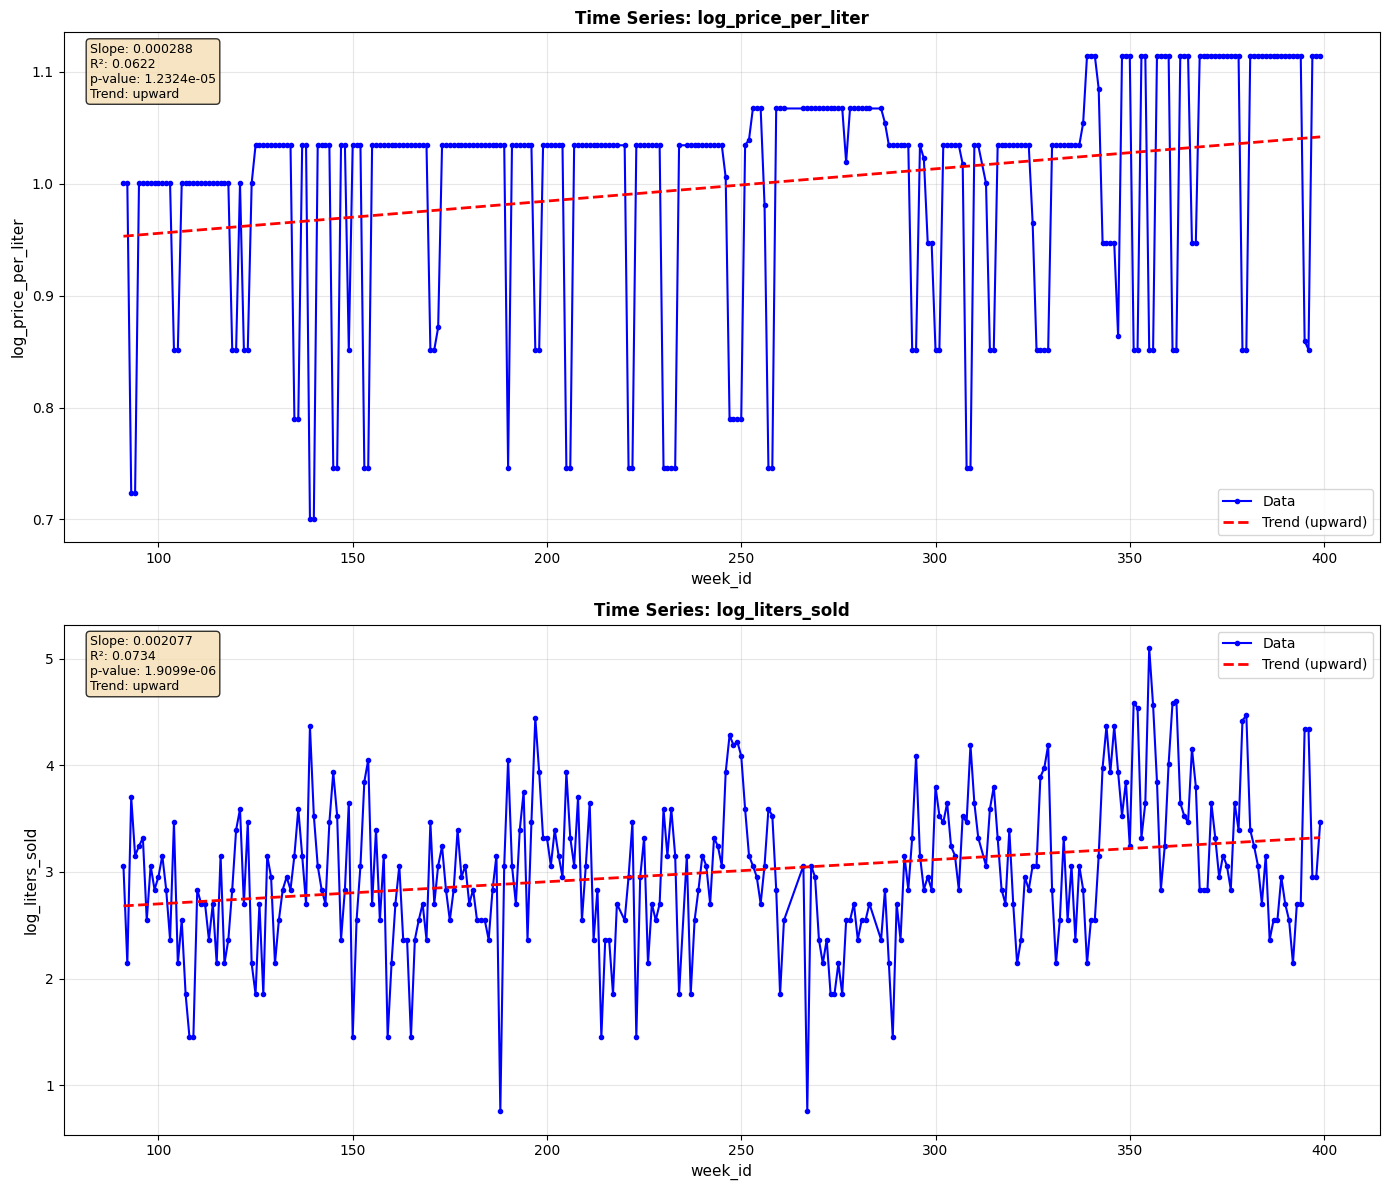

In [26]:
# -------------------------------------------------------------------------
# 9. Tendencias
# -------------------------------------------------------------------------
print("\n=== Trend Analysis ===")
trend_stats = {}
for col in value_cols:
    trend = eda.analyze_trend(ts_df, time_col, col)
    trend_stats[col] = trend
    print(f"\n{col}:")
    print(f"  Slope: {trend['slope']:.6f}")
    print(f"  R²: {trend['r_squared']:.4f}")
    print(f"  p-value: {trend['pvalue']:.4e}")
    print(f"  Trend: {trend['trend_direction']}")

print("\n=== Time Series + Trend Plots ===")
fig_ts = eda.plot_time_series(
    ts_df,
    time_col,
    value_cols,
    trend_stats=trend_stats,
)


=== Autocorrelation Analysis ===

log_price_per_liter:
  Has autocorrelation?: True
  Significant lags: [1, 9, 15, 16, 17]

log_liters_sold:
  Has autocorrelation?: True
  Significant lags: [1, 2, 3, 4, 5]


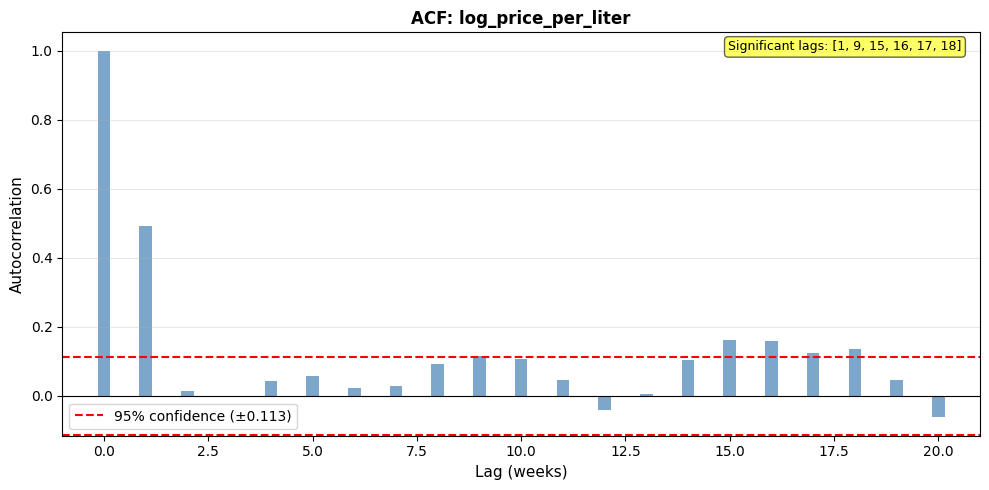

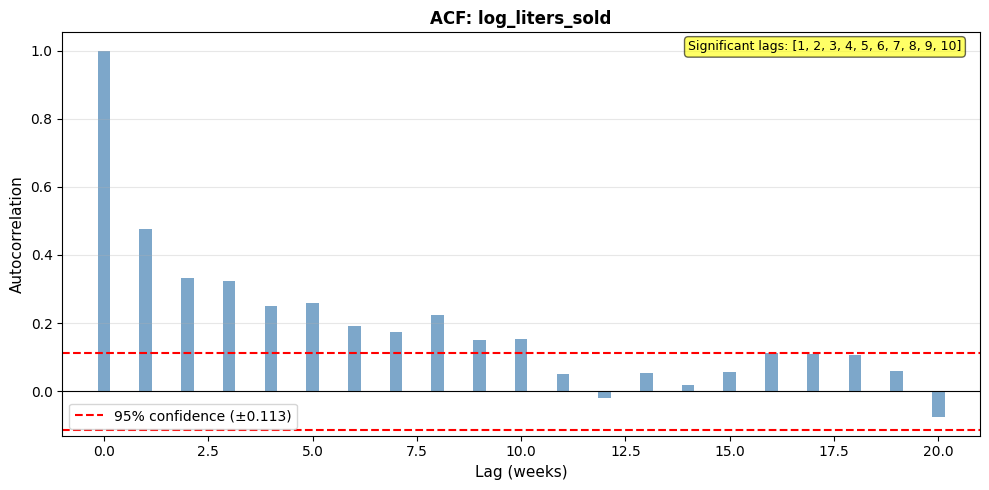

In [27]:
# -------------------------------------------------------------------------
# 10. Autocorrelación
# -------------------------------------------------------------------------
print("\n=== Autocorrelation Analysis ===")
for col in value_cols:
    acf_result = eda.analyze_autocorrelation(ts_df, col, max_lags=20)
    print(f"\n{col}:")
    print(f"  Has autocorrelation?: {acf_result['has_autocorrelation']}")
    if acf_result["significant_lags"]:
        print(f"  Significant lags: {acf_result['significant_lags'][:5]}")

    fig_acf = eda.plot_autocorrelation(
        acf_result,
        title=f"ACF: {col}",
    )

In [28]:
# -------------------------------------------------------------------------
# 11. Estacionalidad
# -------------------------------------------------------------------------
print("\n=== Seasonality Detection (periodo=52 semanas) ===")
for col in value_cols:
    seasonality = eda.detect_seasonality(ts_df, col, period=52)
    print(f"\n{col}:")
    if seasonality.get("note"):
        print(f"  {seasonality['note']}")
    else:
        print(
            f"  ACF in lag {seasonality['period_tested']}: "
            f"{seasonality['seasonal_acf']:.4f}"
        )
        print(f"  Is seasonal?: {seasonality['is_seasonal']}")


=== Seasonality Detection (periodo=52 semanas) ===

log_price_per_liter:
  ACF in lag 52: 0.1177
  Is seasonal?: True

log_liters_sold:
  ACF in lag 52: 0.2478
  Is seasonal?: True
